In [1]:
# All Imports
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib

In [2]:
os.makedirs("charts", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

RANDOM_STATE = 42

print("=" * 50)
print("TITANIC ANALYTICS PIPELINE")
print("=" * 50)
print("\nLOADING TITANIC DATASET")

df = sns.load_dataset("titanic")
df.to_csv("titanic.csv", index=False)

print("\nRaw Titanic dataset successfully saved as titanic.csv")
print("\n--- SHAPE ---")
print(df.shape)
print("\n--- DATAFRAME INFO ---")
df.info()
print("\n--- DESCRIPTIVE STATISTICS ---")
print(df.describe(include="all"))


TITANIC ANALYTICS PIPELINE

LOADING TITANIC DATASET

Raw Titanic dataset successfully saved as titanic.csv

--- SHAPE ---
(891, 15)

--- DATAFRAME INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: 

Data Cleaning

In [3]:
# Missing values Percentage
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_percentage = missing_percentage[missing_percentage > 0]
print("\n--- MISSING VALUE PERCENTAGES ---")
for column, percentage in missing_percentage.items():
    print(f"{column:<15}: {percentage:.2f}%")



--- MISSING VALUE PERCENTAGES ---
deck           : 77.22%
age            : 19.87%
embarked       : 0.22%
embark_town    : 0.22%


In [4]:
# Class Balance
print("\n--- SURVIVAL CLASS BALANCE ---")

class_counts = df["survived"].value_counts().sort_index()
class_percentages = df["survived"].value_counts(normalize=True).sort_index() * 100

print("Counts:")
print(class_counts)

print("\nPercentages:")
print(class_percentages.round(2))



--- SURVIVAL CLASS BALANCE ---
Counts:
survived
0    549
1    342
Name: count, dtype: int64

Percentages:
survived
0    61.62
1    38.38
Name: proportion, dtype: float64


EDA

In [5]:
# Handling Missing Values
print("\n" + "=" * 50)
print("MISSING VALUE HANDLING")
print("=" * 50)

# Work on ONE cleaned copy.
clean_df = df.copy()

# justification for every affected column
for column, percentage in missing_percentage.items():
    if percentage < 5:
        print(f"{column}: {percentage:.2f}% missing -> "
             "UNDER 5%, therefore affected rows will be dropped.")
    elif percentage <= 30:
        print(f"{column}: {percentage:.2f}% missing -> "
              "BETWEEN 5% AND 30%, therefore values will be imputed.")
    else:
        print(f"{column}: {percentage:.2f}% missing -> "
              "MORE THAN 30%; reliable statistical imputation is questionable.")

#  Age 19.9% missing -> median imputation
if clean_df["age"].isnull().any():
    age_missing_pct = df["age"].isnull().mean() * 100

    if 5 <= age_missing_pct <= 30:
        age_median = clean_df["age"].median()
        clean_df["age"] = clean_df["age"].fillna(age_median)
        print(f"\nage = {age_missing_pct:.2f}% missing. "
              f"Median-imputed with {age_median:.2f}.")

# embarked <5% missing -> drop affected rows
embarked_missing_pct = df["embarked"].isnull().mean() * 100
if 0 < embarked_missing_pct < 5:
    clean_df = clean_df[clean_df["embarked"].notna()].copy()
    print(f"embarked = {embarked_missing_pct:.2f}% missing. "
           "Rows dropped because missing rate is under 5%.")

# embark_town <5% missing -> same rows correspond to missing embarked
embark_town_missing_pct = df["embark_town"].isnull().mean() * 100
if 0 < embark_town_missing_pct < 5:
    clean_df = clean_df[clean_df["embark_town"].notna()].copy()
    print(f"embark_town = {embark_town_missing_pct:.2f}% missing. "
          "Rows dropped because missing rate is under 5%.")

# deck very high missing percentage -> DROP COLUMN
deck_missing_pct = df["deck"].isnull().mean() * 100
if deck_missing_pct > 30:
    clean_df = clean_df.drop(columns=["deck"])
    print(f"deck = {deck_missing_pct:.2f}% missing. "
           "Column dropped because the missing rate is very high, "
           "making statistical imputation unreliable.")

print("\nCleaned dataset shape:")
print(clean_df.shape)
print("\nRemaining missing values:")
print(clean_df.isnull().sum()[clean_df.isnull().sum() > 0])


MISSING VALUE HANDLING
deck: 77.22% missing -> MORE THAN 30%; reliable statistical imputation is questionable.
age: 19.87% missing -> BETWEEN 5% AND 30%, therefore values will be imputed.
embarked: 0.22% missing -> UNDER 5%, therefore affected rows will be dropped.
embark_town: 0.22% missing -> UNDER 5%, therefore affected rows will be dropped.

age = 19.87% missing. Median-imputed with 28.00.
embarked = 0.22% missing. Rows dropped because missing rate is under 5%.
embark_town = 0.22% missing. Rows dropped because missing rate is under 5%.
deck = 77.22% missing. Column dropped because the missing rate is very high, making statistical imputation unreliable.

Cleaned dataset shape:
(889, 14)

Remaining missing values:
Series([], dtype: int64)



 BIVARIATE ANALYSIS

Survival by sex:
Male survival rate   : 18.89%
Female survival rate : 74.04%

Survival by passenger class:
Class 1: 62.62%
Class 2: 47.28%
Class 3: 24.24%

Survival by sex AND passenger class:
Female, Class 1: 96.74%
Female, Class 2: 92.11%
Female, Class 3: 50.00%
Male, Class 1: 36.89%
Male, Class 2: 15.74%
Male, Class 3: 13.54%

Survival rate for passengers who were female OR first-class:
63.59%

Exact 6 x 6 correlation matrix:
          survived  pclass    age  sibsp  parch   fare
survived     1.000  -0.336 -0.070 -0.034  0.083  0.255
pclass      -0.336   1.000 -0.337  0.082  0.017 -0.548
age         -0.070  -0.337  1.000 -0.233 -0.171  0.094
sibsp       -0.034   0.082 -0.233  1.000  0.415  0.161
parch        0.083   0.017 -0.171  0.415  1.000  0.218
fare         0.255  -0.548  0.094  0.161  0.218  1.000


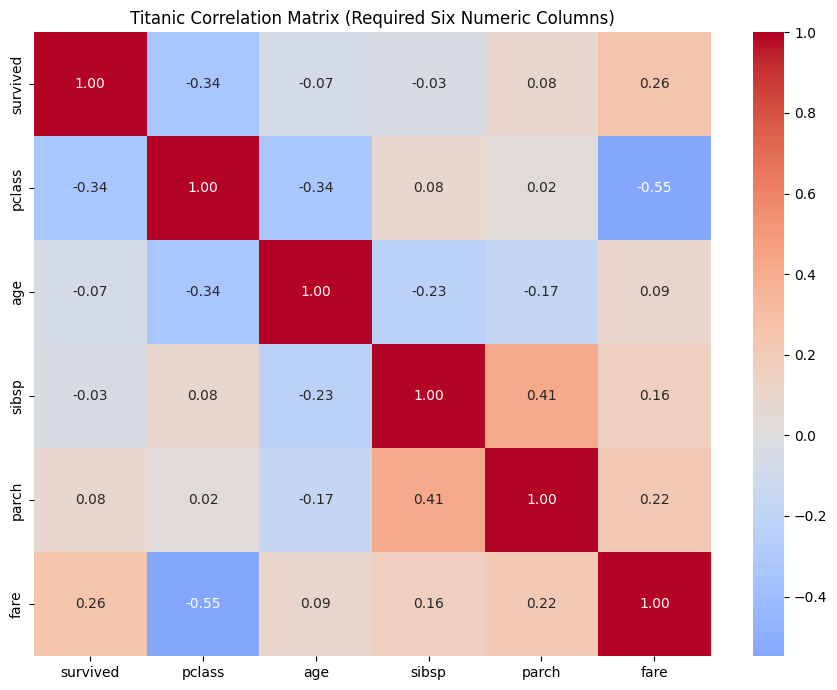


Two strongest absolute off-diagonal correlations:
1. pclass vs fare: -0.548
2. sibsp vs parch: 0.415


In [6]:
# BIVARIATE ANALYSIS
print("\n" + "=" * 50)
print(" BIVARIATE ANALYSIS")
print("=" * 50)

#  Survival by sex using boolean masking
male_mask = clean_df["sex"] == "male"
female_mask = clean_df["sex"] == "female"
male_survival_rate = (clean_df.loc[male_mask, "survived"].mean() * 100)
female_survival_rate = (clean_df.loc[female_mask, "survived"].mean() * 100)
print("\nSurvival by sex:")
print(f"Male survival rate   : "
      f"{male_survival_rate:.2f}%")
print(f"Female survival rate : "
      f"{female_survival_rate:.2f}%")

# survival by pclass using boolean asking
print("\nSurvival by passenger class:")
pclass_survival_rates = {}
for passenger_class in [1, 2, 3]:
    class_mask = (clean_df["pclass"] == passenger_class)
    survival_rate = (clean_df.loc[class_mask,"survived"].mean() * 100)
    pclass_survival_rates[passenger_class] = survival_rate
    print(f"Class {passenger_class}: "
          f"{survival_rate:.2f}%")

# sex + pclass with and boolean masking
print("\nSurvival by sex AND passenger class:")
sex_class_survival = {}
for sex in ["female", "male"]:
    for passenger_class in [1, 2, 3]:
        combined_mask = (
            (clean_df["sex"] == sex)
            &
            (clean_df["pclass"] == passenger_class)
        )

        rate = (clean_df.loc[combined_mask,"survived"].mean() * 100)
        sex_class_survival[(sex, passenger_class)] = rate

        print(f"{sex.capitalize()}, "f"Class {passenger_class}: "
            f"{rate:.2f}%")


# example using | boolean operator
female_or_first_class_mask = (
    (clean_df["sex"] == "female")
    |
    (clean_df["pclass"] == 1))
female_or_first_class_rate = (
    clean_df.loc[female_or_first_class_mask,"survived"].mean() * 100)

print("\nSurvival rate for passengers who were "
      "female OR first-class:")
print(f"{female_or_first_class_rate:.2f}%")

# Exact six coloumn correlation matrix
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = (clean_df[correlation_columns].corr())
print("\nExact 6 x 6 correlation matrix:")
print(correlation_matrix.round(3))

# Correlation heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(correlation_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0)
plt.title("Titanic Correlation Matrix "
          "(Required Six Numeric Columns)")
plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png",dpi=300)
plt.show()

# Find top 2 absolute off-diagnol correlation
correlation_pairs = []
for i in range(len(correlation_columns)):
    for j in range(i + 1, len(correlation_columns)):
        col1 = correlation_columns[i]
        col2 = correlation_columns[j]
        corr_value = correlation_matrix.loc[col1,col2]
        correlation_pairs.append((col1,col2,corr_value,abs(corr_value)))
correlation_pairs.sort(key=lambda x: x[3],reverse=True)
top_two_correlations = correlation_pairs[:2]
print("\nTwo strongest absolute "
      "off-diagonal correlations:")

for rank, (col1,col2,corr,abs_corr) in enumerate(top_two_correlations,start=1):
    print(f"{rank}. {col1} vs {col2}: "f"{corr:.3f}")



MULTIVARIATE DATA STORY


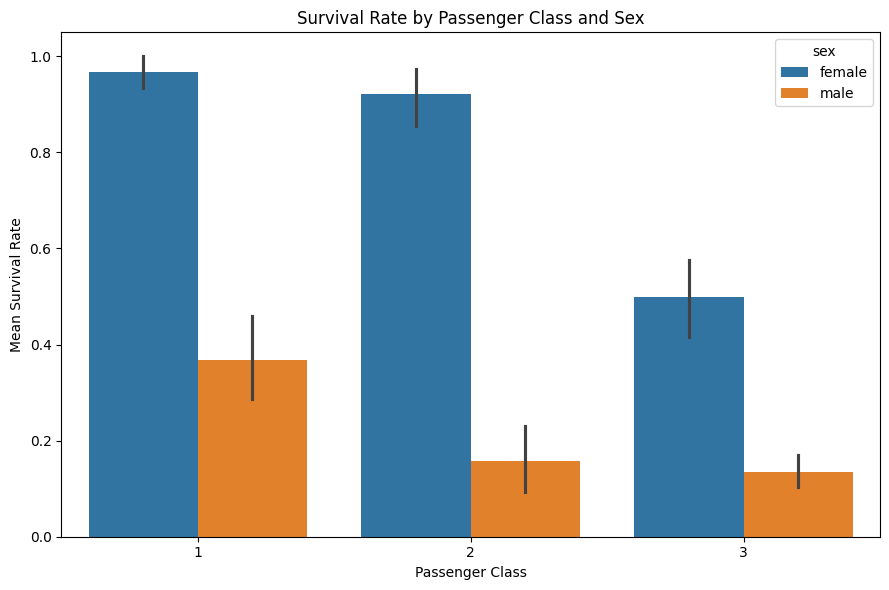


Chart 1 Interpretation:
Survival probability differs substantially by both sex and passenger class.
Female passengers generally experienced higher survival rates than male
passengers, while passengers in higher travel classes also tended to survive
more frequently. This suggests both gender and socioeconomic position were
strongly associated with survival.



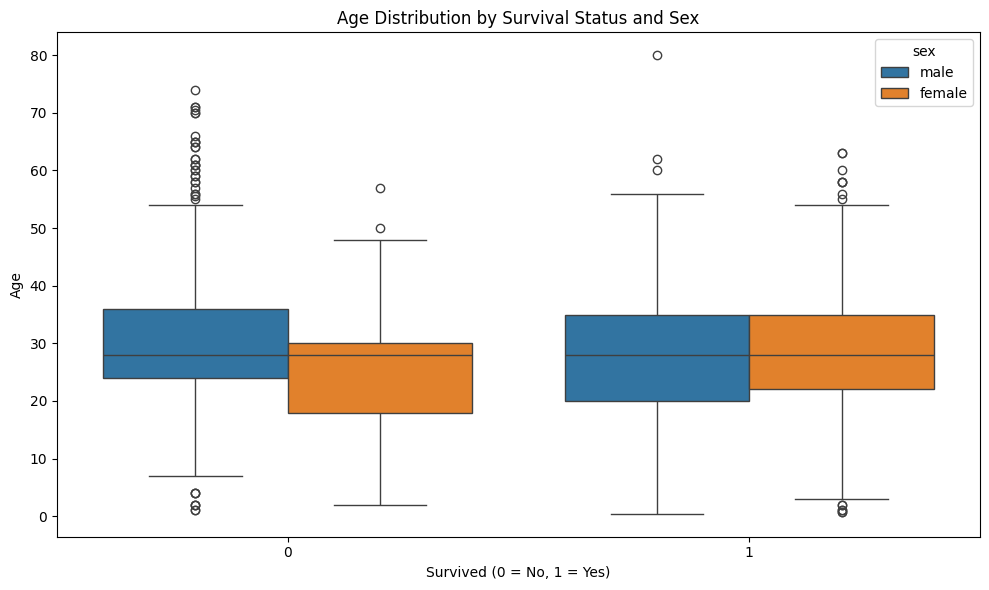


Chart 2 Interpretation:
The age distributions of survivors and non-survivors overlap substantially,
which indicates that age by itself does not fully explain survival.
However, viewing age together with sex reveals important differences between
passenger groups and reinforces the need for multivariate modeling.



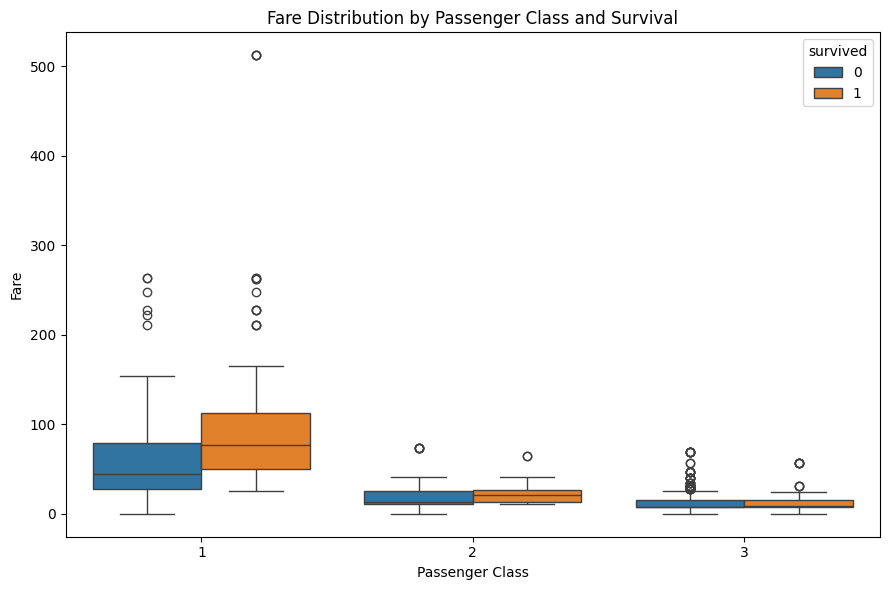


Chart 3 Interpretation:
Fare is closely related to passenger class, with first-class passengers
generally paying substantially higher fares. Survivors are more concentrated
among the higher-fare groups, suggesting that fare partly captures differences
in cabin location, class and access to evacuation opportunities.



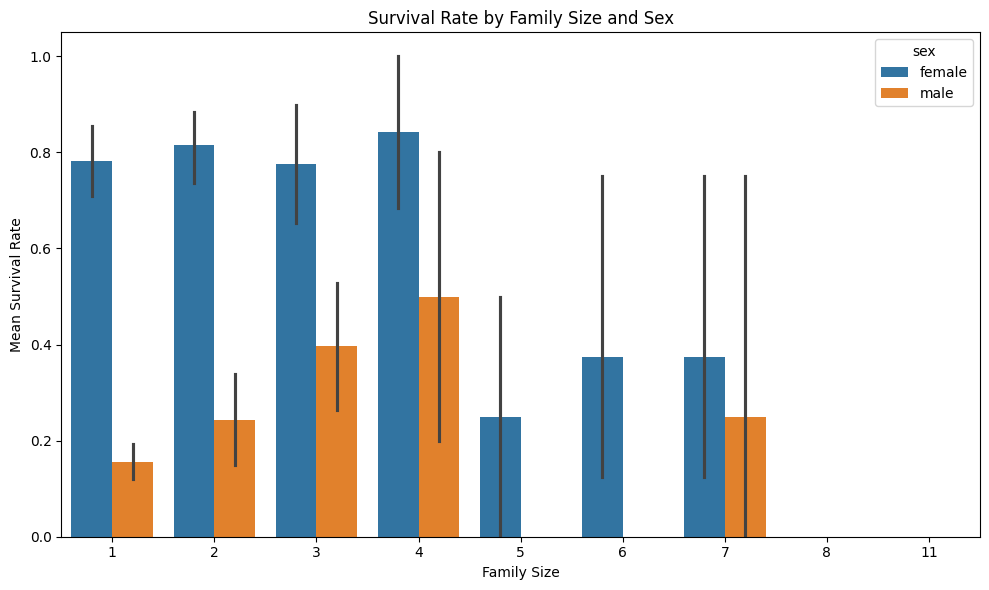


Chart 4 Interpretation:
Survival varies with family size rather than changing monotonically as the
number of relatives increases. Very large groups can show lower survival,
while some small family groups appear to perform better than passengers in
large families. Sex remains an important differentiating factor even after
family structure is considered.



In [7]:
# Multivariate Data Story
print("\n" + "=" * 50)
print("MULTIVARIATE DATA STORY")
print("=" * 50)

# Chart 1 - Sex + Class vs Survival
plt.figure(figsize=(9, 6))
sns.barplot(data=clean_df,
            x="pclass",
            y="survived",
            hue="sex")
plt.title("Survival Rate by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Mean Survival Rate")
plt.tight_layout()
plt.savefig("charts/survival_sex_class.png",dpi=300)
plt.show()

print("""
Chart 1 Interpretation:
Survival probability differs substantially by both sex and passenger class.
Female passengers generally experienced higher survival rates than male
passengers, while passengers in higher travel classes also tended to survive
more frequently. This suggests both gender and socioeconomic position were
strongly associated with survival.
""")

# Chart 2 - AGE + SEX + SURVIVAL
plt.figure(figsize=(10, 6))
sns.boxplot(data=clean_df,x="survived",y="age",hue="sex")
plt.title("Age Distribution by Survival Status and Sex")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig("charts/survival_age.png",dpi=300)
plt.show()
print("""
Chart 2 Interpretation:
The age distributions of survivors and non-survivors overlap substantially,
which indicates that age by itself does not fully explain survival.
However, viewing age together with sex reveals important differences between
passenger groups and reinforces the need for multivariate modeling.
""")

# Chart 3 - FARE + CLASS + SURVIVAL
plt.figure(figsize=(9, 6))
sns.boxplot(data=clean_df,
            x="pclass",
            y="fare",
            hue="survived")

plt.title("Fare Distribution by Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.tight_layout()
plt.savefig("charts/fare_survival.png",dpi=300)
plt.show()

print("""
Chart 3 Interpretation:
Fare is closely related to passenger class, with first-class passengers
generally paying substantially higher fares. Survivors are more concentrated
among the higher-fare groups, suggesting that fare partly captures differences
in cabin location, class and access to evacuation opportunities.
""")

# Chart 4 - FAMILY SIZE + SEX + SURVIVAL
story_df = clean_df.copy()
story_df["family_size"] = (story_df["sibsp"]+story_df["parch"]+1)

plt.figure(figsize=(10, 6))
sns.barplot(data=story_df,
            x="family_size",
            y="survived",
            hue="sex")
plt.title("Survival Rate by Family Size and Sex")
plt.xlabel("Family Size")
plt.ylabel("Mean Survival Rate")
plt.tight_layout()
plt.savefig("charts/family_survival.png",dpi=300)
plt.show()

print("""
Chart 4 Interpretation:
Survival varies with family size rather than changing monotonically as the
number of relatives increases. Very large groups can show lower survival,
while some small family groups appear to perform better than passengers in
large families. Sex remains an important differentiating factor even after
family structure is considered.
""")

Test Train Split

In [8]:
# Exploratory Z-SCORE Standardization
print("\n" + "=" * 50)
print(" EXPLORATORY STANDARDIZATION CHECK")
print("=" * 50)

eda_scaled = clean_df[["age", "fare"]].copy()
print("\nBEFORE STANDARDIZATION")
before_summary = pd.DataFrame({
    "Mean": eda_scaled.mean(),
    "Std": eda_scaled.std(ddof=0)
})
print(before_summary)

# StandardScaler uses population SD internally.
eda_scaler = StandardScaler()
scaled_values = eda_scaler.fit_transform(eda_scaled)
eda_scaled[["age_z", "fare_z"]] = scaled_values
after_summary = pd.DataFrame({
    "Mean": [
        eda_scaled["age_z"].mean(),
        eda_scaled["fare_z"].mean()
    ],

    "Std": [
        eda_scaled["age_z"].std(ddof=0),
        eda_scaled["fare_z"].std(ddof=0)
    ]
}, index=["age_z", "fare_z"])

print("\nAFTER STANDARDIZATION")
print(after_summary)
print("\nBoth standardized variables should have "
      "approximately mean = 0 and standard deviation = 1.")

# Stratified TRAIN/TEST SPLIT
print("\n" + "=" * 50)
print("STRATIFIED TRAIN/TEST SPLIT")
print("=" * 50)

classification_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
    "sex",
    "embarked"
]


X = clean_df[classification_features].copy()
y = clean_df["survived"].copy()
print("\nOverall target proportions:")
print(y.value_counts(normalize=True).sort_index().round(4))

X_train, X_test, y_train, y_test = (train_test_split(X,y,test_size=0.20,
                                    random_state=RANDOM_STATE,stratify=y))

print("\nTraining target proportions:")
print(y_train.value_counts(normalize=True).sort_index().round(4))
print("\nTesting target proportions:")
print(y_test.value_counts(normalize=True).sort_index().round(4))
print("""
Stratification is important because the Titanic target classes are not evenly
distributed. Using stratify=y preserves approximately the same survivor and
non-survivor proportions in both training and testing data, preventing the
evaluation split from accidentally over- or under-representing either class.
""")



 EXPLORATORY STANDARDIZATION CHECK

BEFORE STANDARDIZATION
           Mean        Std
age   29.315152  12.977627
fare  32.096681  49.669545

AFTER STANDARDIZATION
                Mean  Std
age_z   2.717486e-16  1.0
fare_z  1.398706e-16  1.0

Both standardized variables should have approximately mean = 0 and standard deviation = 1.

STRATIFIED TRAIN/TEST SPLIT

Overall target proportions:
survived
0    0.6175
1    0.3825
Name: proportion, dtype: float64

Training target proportions:
survived
0    0.6174
1    0.3826
Name: proportion, dtype: float64

Testing target proportions:
survived
0    0.618
1    0.382
Name: proportion, dtype: float64

Stratification is important because the Titanic target classes are not evenly
distributed. Using stratify=y preserves approximately the same survivor and
non-survivor proportions in both training and testing data, preventing the
evaluation split from accidentally over- or under-representing either class.



In [9]:
# Train-only preprocessin
print("\n" + "=" * 50)
print("PREPROCESSING PIPELINE")
print("=" * 50)

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]
categorical_features = ["sex","embarked"]

# Numeric:
# median imputation -> scaling
numeric_transformer = Pipeline(
    steps=[("imputer",SimpleImputer(strategy="median")),
          ("scaler",StandardScaler())])

# Categorical:
# most frequent -> one-hot
categorical_transformer = Pipeline(
    steps=[("imputer",SimpleImputer(strategy="most_frequent")),
        ("onehot",OneHotEncoder(handle_unknown="ignore",sparse_output=False))])

preprocessor = ColumnTransformer(
    transformers=[("num",numeric_transformer,numeric_features),
                  ("cat",categorical_transformer,categorical_features)])
print("""
The preprocessing object is NOT fitted manually on the complete dataset.
Each classifier receives the ColumnTransformer inside its Pipeline. Calling
pipeline.fit(X_train, y_train) therefore fits imputers, encoder and scaler only
on training data. pipeline.predict(X_test) applies those already-fitted
transformations to test data without refitting them.
""")



PREPROCESSING PIPELINE

The preprocessing object is NOT fitted manually on the complete dataset.
Each classifier receives the ColumnTransformer inside its Pipeline. Calling
pipeline.fit(X_train, y_train) therefore fits imputers, encoder and scaler only
on training data. pipeline.predict(X_test) applies those already-fitted
transformations to test data without refitting them.



Models Pipeline


TRAINING THREE CLASSIFIERS
Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


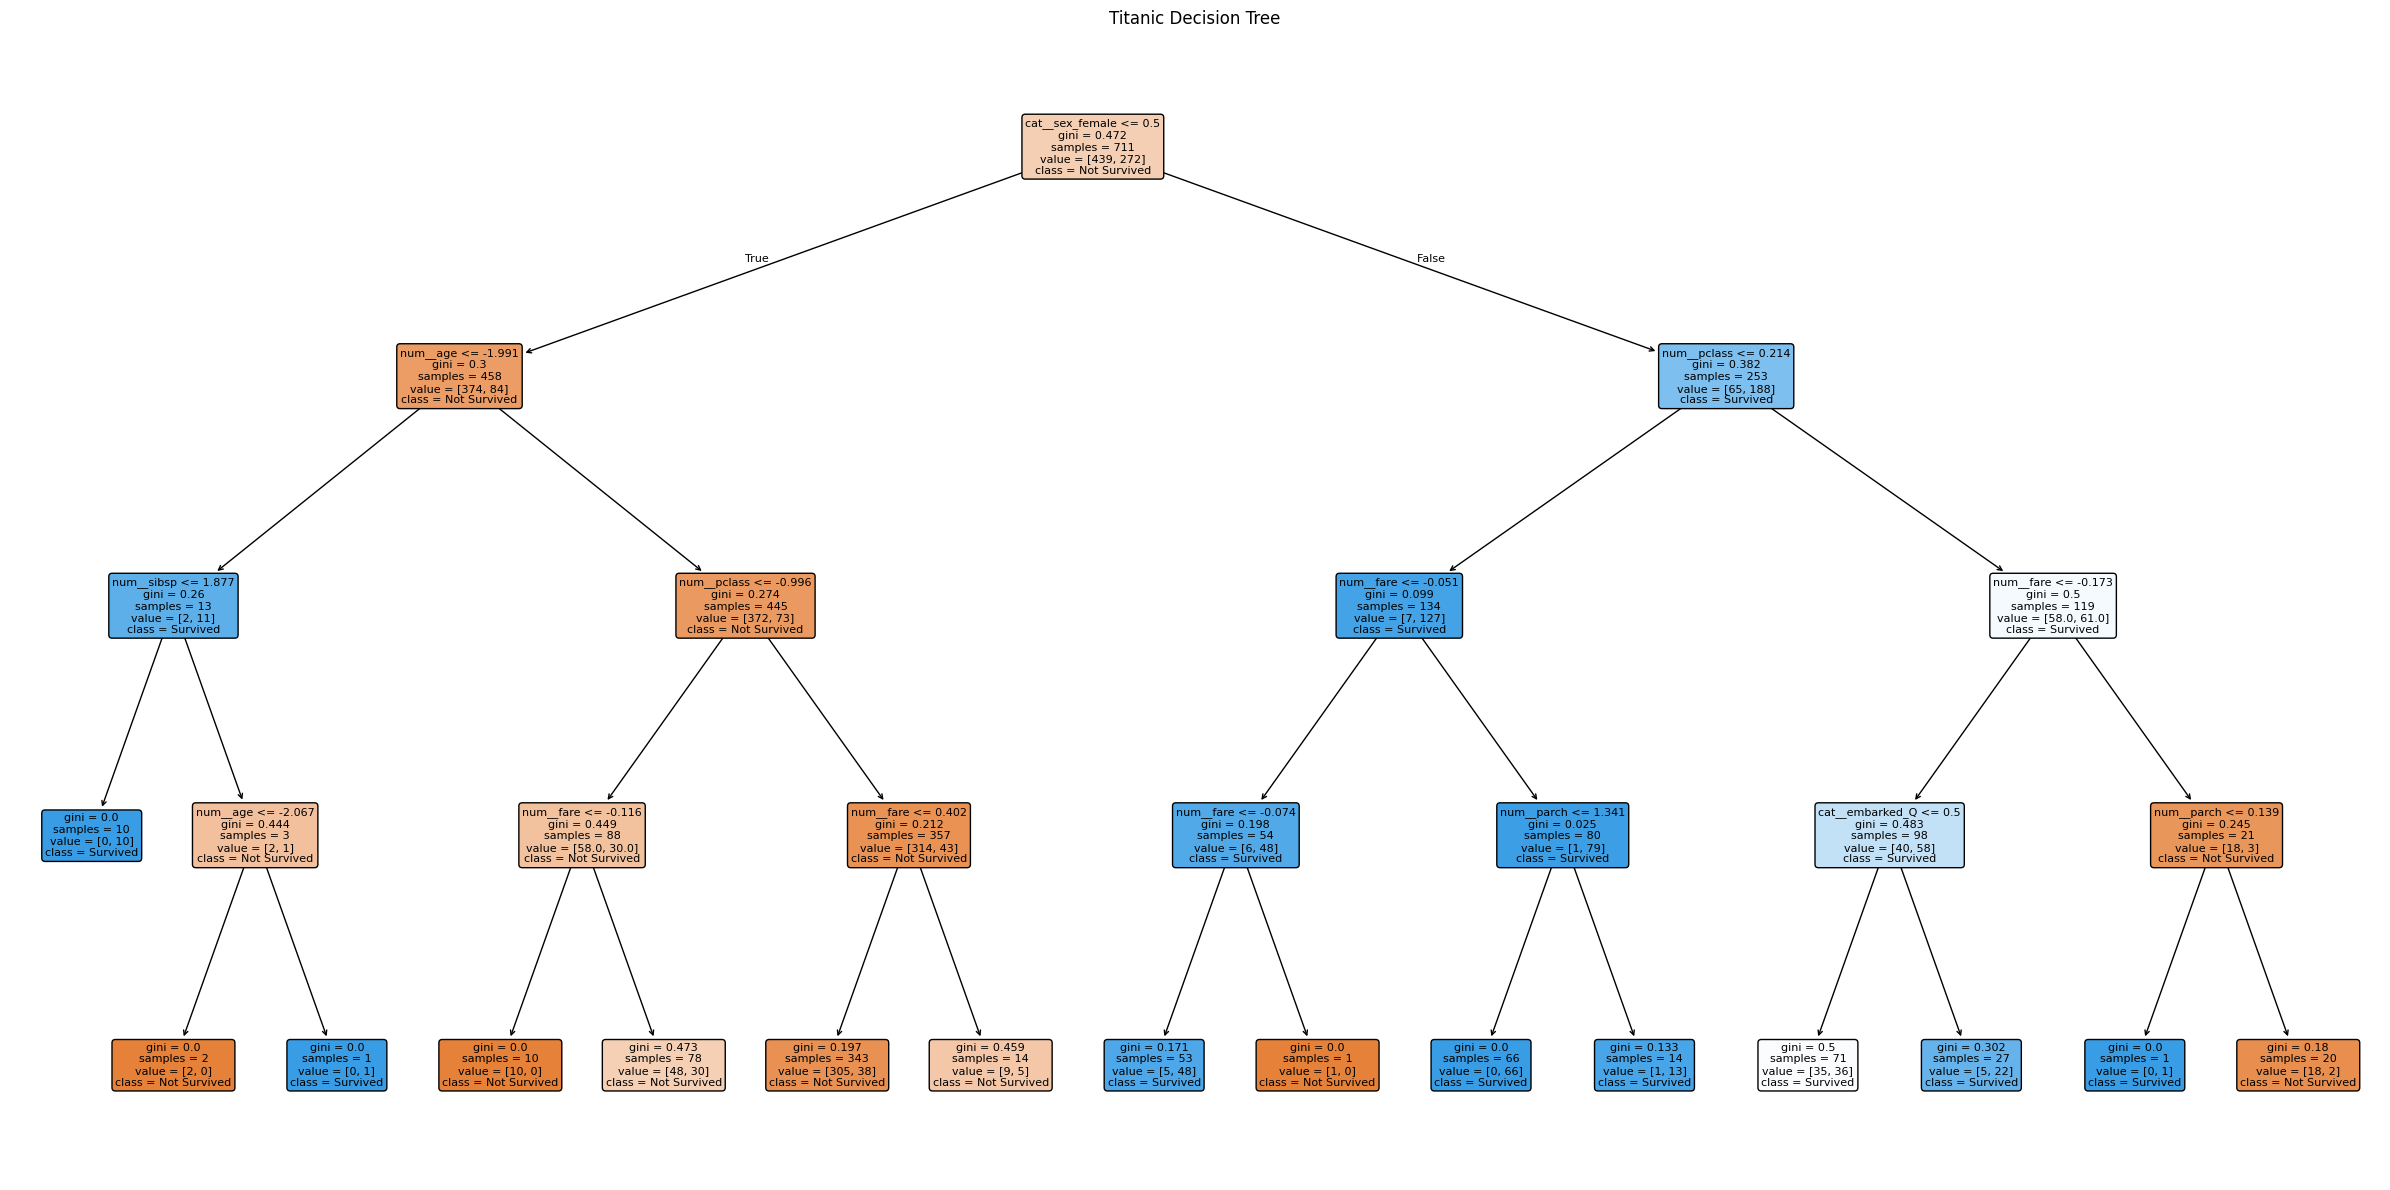

In [10]:
# Three Classifiers
print("\n" + "=" * 50)
print("TRAINING THREE CLASSIFIERS")
print("=" * 50)

models = {"Logistic Regression":
          LogisticRegression(max_iter=1000,random_state=RANDOM_STATE),

          "Decision Tree":
          DecisionTreeClassifier(max_depth=4,random_state=RANDOM_STATE),

          "Random Forest":
          RandomForestClassifier(n_estimators=200,random_state=RANDOM_STATE)}

pipelines = {}
for model_name, estimator in models.items():
    pipeline = Pipeline(
        steps=[("preprocess",preprocessor),
               ("classifier",estimator)])

    pipeline.fit(X_train,y_train)
    pipelines[model_name] = pipeline

    print(f"{model_name} trained successfully.")

# Decision Tree Visualization
tree_pipeline = pipelines["Decision Tree"]
feature_names = (tree_pipeline
                 .named_steps["preprocess"]
                 .get_feature_names_out())
tree_model = (tree_pipeline.named_steps["classifier"])

plt.figure(figsize=(24, 12))
plot_tree(tree_model,
          feature_names=feature_names,
          class_names=[ "Not Survived","Survived"],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title("Titanic Decision Tree")
plt.tight_layout()
plt.savefig("charts/decision_tree.png",dpi=300)
plt.show()

Confusion Matrix and Model Evaluation


CLASSIFIER EVALUATION

Logistic Regression Confusion Matrix:
[[97 13]
 [21 47]]


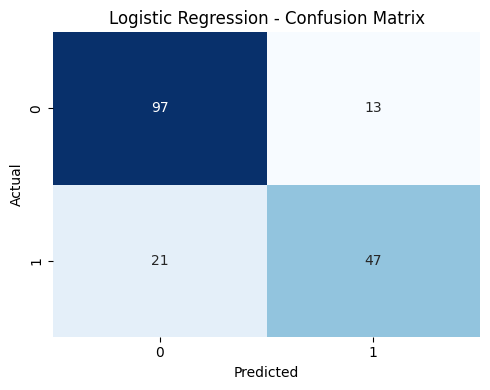


Decision Tree Confusion Matrix:
[[100  10]
 [ 24  44]]


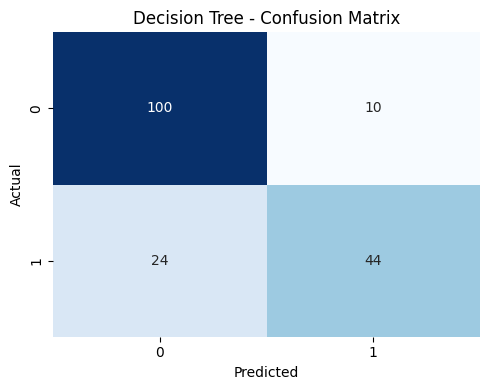


Random Forest Confusion Matrix:
[[95 15]
 [19 49]]


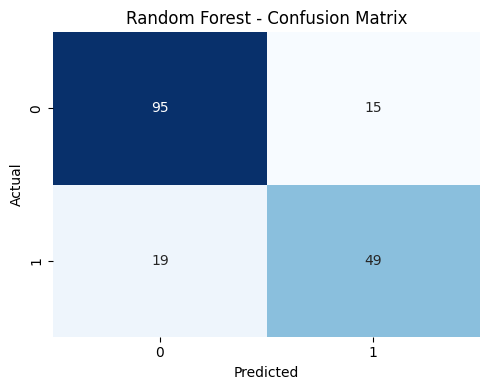


CLASSIFICATION MODEL COMPARISON
                     Accuracy  Precision  Recall      F1     AUC
Model                                                           
Logistic Regression     0.809     0.7833  0.6912  0.7344  0.8610
Decision Tree           0.809     0.8148  0.6471  0.7213  0.8560
Random Forest           0.809     0.7656  0.7206  0.7424  0.8196


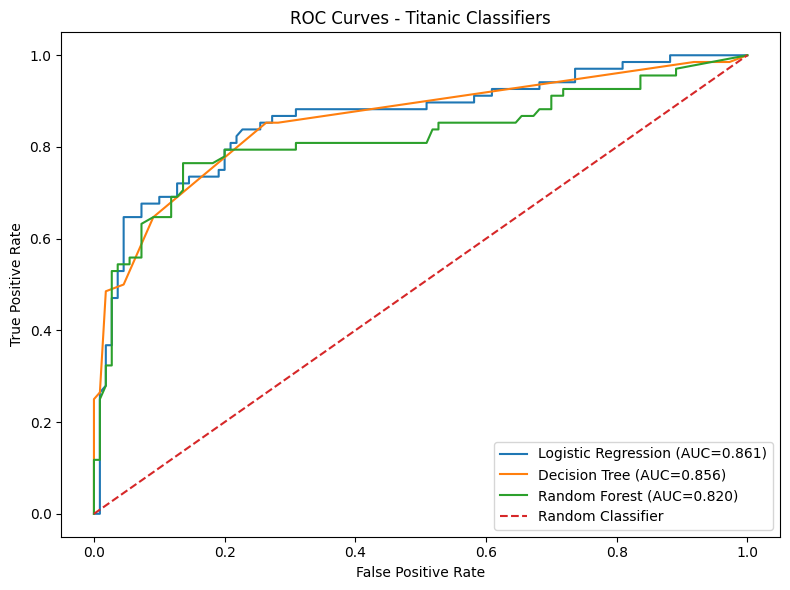

In [11]:
# Classifier Evaluation
print("\n" + "=" * 50)
print("CLASSIFIER EVALUATION")
print("=" * 50)

classification_results = []
roc_information = {}

for model_name, pipeline in pipelines.items():
    predictions = pipeline.predict(X_test)
    probabilities = (pipeline.predict_proba(X_test)[:, 1])
    accuracy = accuracy_score(y_test,predictions)
    precision = precision_score(y_test,predictions,zero_division=0)
    recall = recall_score(y_test,predictions,zero_division=0)
    f1 = f1_score(y_test,predictions,zero_division=0)
    auc = roc_auc_score(y_test,probabilities)
    classification_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    })

    # Confusion Matrix
    cm = confusion_matrix(y_test,predictions)
    print(f"\n{model_name} Confusion Matrix:")
    print(cm)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",cbar=False)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    filename = (model_name.lower().replace(" ", "_"))
    plt.tight_layout()
    plt.savefig(f"charts/{filename}_confusion_matrix.png",dpi=300)
    plt.show()

    # ROC data
    fpr, tpr, _ = roc_curve(y_test,probabilities)
    roc_information[model_name] = (fpr,tpr,auc)

classification_table = pd.DataFrame(classification_results).set_index("Model")

print("\nCLASSIFICATION MODEL COMPARISON")
print(classification_table.round(4))
classification_table.to_csv("outputs/model_comparison.csv")

# ROC CURVES
plt.figure(figsize=(8, 6))
for model_name, (fpr,tpr,auc) in roc_information.items():
    plt.plot(fpr,tpr,label=f"{model_name} (AUC={auc:.3f})")

plt.plot([0, 1],
         [0, 1],
         linestyle="--",
         label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Titanic Classifiers")
plt.legend()
plt.tight_layout()
plt.savefig("charts/roc_curves.png",dpi=300)
plt.show()

In [12]:
# Imbalance Handling
print("\n" + "=" * 50)
print("IMBALANCE HANDLING")
print("=" * 50)
print("\nClass balance:")
balance_table = pd.DataFrame({"Count":y.value_counts().sort_index(),
                              "Percentage":
                               (y.value_counts(normalize=True)
                               .sort_index()* 100)})
print(balance_table.round(2))
imbalance_results = []

# Baseline Logistic Regression
baseline_pipeline = Pipeline(
    steps=[("preprocess",preprocessor),
           ("classifier",LogisticRegression(max_iter=1000,
                                            random_state=RANDOM_STATE))])
baseline_pipeline.fit(X_train,y_train)
baseline_predictions = (baseline_pipeline.predict(X_test))

imbalance_results.append({
    "Strategy": "Baseline",
    "Precision":precision_score(y_test,baseline_predictions),
    "Recall":recall_score(y_test,baseline_predictions),
    "F1":f1_score(y_test,baseline_predictions)})

# class_weight=balanced
balanced_pipeline = Pipeline(
    steps=[
        ("preprocess",preprocessor),
        ("classifier",LogisticRegression(max_iter=1000,
                                         class_weight="balanced",
                                         random_state=RANDOM_STATE))])
balanced_pipeline.fit(X_train,y_train)
balanced_predictions = (balanced_pipeline.predict(X_test))

imbalance_results.append({
    "Strategy":"Class Weight Balanced",
    "Precision":precision_score(y_test,balanced_predictions),
    "Recall":recall_score(y_test,balanced_predictions),
    "F1":f1_score(y_test,balanced_predictions)})

# SMOTE
# IMPORTANT:preprocessor.fit_transform occurs on training data.
# SMOTE then sees ONLY the training representation.
# Test data is never oversampled.

smote_pipeline = ImbPipeline(
    steps=[
        ("preprocess",preprocessor),
        ("smote",SMOTE(random_state=RANDOM_STATE)),
        ("classifier",LogisticRegression(max_iter=1000,
                                         random_state=RANDOM_STATE))])

smote_pipeline.fit(X_train,y_train)
smote_predictions = (smote_pipeline.predict(X_test))
imbalance_results.append({
    "Strategy":"SMOTE",
    "Precision":precision_score(y_test,smote_predictions),
    "Recall":recall_score(y_test,smote_predictions),
    "F1":f1_score(y_test,smote_predictions)})

imbalance_table = (pd.DataFrame(imbalance_results).set_index("Strategy"))

print("\nIMBALANCE STRATEGY COMPARISON")
print(imbalance_table.round(4))

imbalance_table.to_csv("outputs/imbalance_comparison.csv")
best_imbalance_strategy = (imbalance_table["F1"].idxmax())
print(f"\nBased on test F1, the strongest "
      f"imbalance strategy is "
      f"{best_imbalance_strategy}.")
print("Its precision, recall and F1 should be "
      "considered together rather than optimizing "
      "only accuracy.")


IMBALANCE HANDLING

Class balance:
          Count  Percentage
survived                   
0           549       61.75
1           340       38.25

IMBALANCE STRATEGY COMPARISON
                       Precision  Recall      F1
Strategy                                        
Baseline                  0.7833  0.6912  0.7344
Class Weight Balanced     0.7183  0.7500  0.7338
SMOTE                     0.7353  0.7353  0.7353

Based on test F1, the strongest imbalance strategy is SMOTE.
Its precision, recall and F1 should be considered together rather than optimizing only accuracy.


Hyperparameter Tuning for Randomn Forest

In [13]:
# RANDOM FOREST GRID SEARCH + OOB
print("\n" + "=" * 50)
print("RANDOM FOREST HYPERPARAMETER TUNING")
print("=" * 50)

rf_for_tuning = RandomForestClassifier(oob_score=True,
                                       bootstrap=True,
                                      random_state=RANDOM_STATE,
                                       n_jobs=-1)
rf_tuning_pipeline = Pipeline(
    steps=[("preprocess",preprocessor),
           ("classifier",rf_for_tuning)])
parameter_grid = {
    "classifier__n_estimators":[100, 200, 300],
    "classifier__max_depth":[None, 5, 10],
    "classifier__max_features":["sqrt", "log2"]}

grid_search = GridSearchCV(estimator=rf_tuning_pipeline,
                           param_grid=parameter_grid,
                           scoring="f1",
                           cv=5,
                           n_jobs=-1,
                           verbose=1)

grid_search.fit(X_train,y_train)
print("\nBest parameters:")
print(grid_search.best_params_)
print("\nBest cross-validation F1:")
print(round(grid_search.best_score_,4))
best_rf_pipeline = (grid_search.best_estimator_)
best_rf_estimator = (best_rf_pipeline.named_steps["classifier"])

print("\nOOB Score:")
print(round(best_rf_estimator.oob_score_,4))

# Evaluate tuned Randomn Forest
tuned_rf_predictions = (best_rf_pipeline.predict(X_test))
tuned_rf_probabilities = (best_rf_pipeline.predict_proba(X_test)[:, 1])
tuned_rf_metrics = {"Accuracy":accuracy_score(y_test,tuned_rf_predictions),
                    "Precision":precision_score(y_test,tuned_rf_predictions),
                    "Recall":recall_score(y_test,tuned_rf_predictions),
                    "F1":f1_score(y_test,tuned_rf_predictions),
                    "AUC":roc_auc_score(y_test,tuned_rf_probabilities)}

print("\nTuned Random Forest test metrics:")
for metric, value in (tuned_rf_metrics.items()):
    print(f"{metric}: {value:.4f}")


RANDOM FOREST HYPERPARAMETER TUNING
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best parameters:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 300}

Best cross-validation F1:
0.7449

OOB Score:
0.8073

Tuned Random Forest test metrics:
Accuracy: 0.8034
Precision: 0.7619
Recall: 0.7059
F1: 0.7328
AUC: 0.8237


Multi-Variate Linear Regression


MULTIVARIATE LINEAR REGRESSION

REGRESSION METRICS
                                MAE     RMSE      R2  Adjusted R2
Model                                                            
Multiple Linear Regression  21.0986  41.7021  0.3482       0.3091


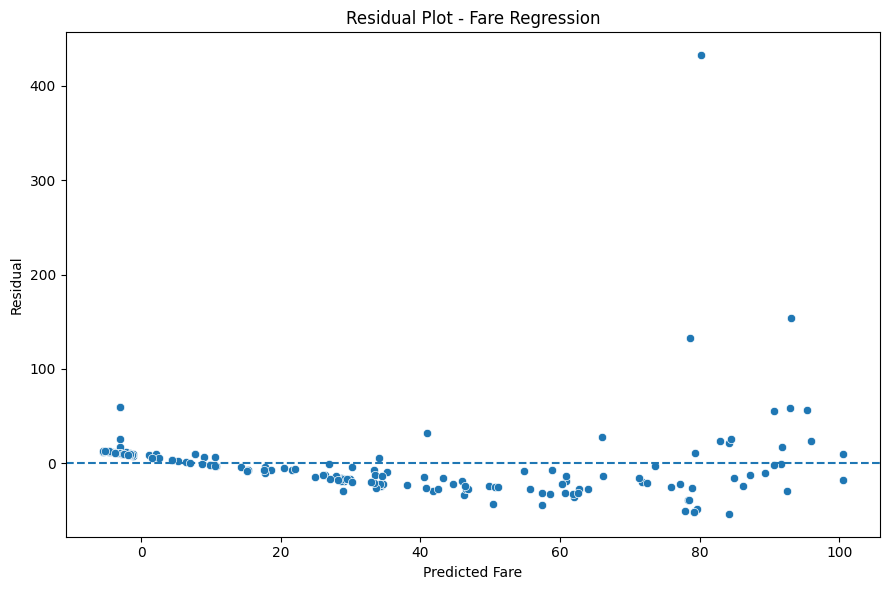


Residual interpretation:
The residual plot shows evidence of heteroscedasticity because residual spread changes as predicted fare changes.
Correlation between predicted fare and absolute residual magnitude: 0.3368


In [14]:
# Regression Side Task
# Predict Fare
print("\n" + "=" * 50)
print("MULTIVARIATE LINEAR REGRESSION")
print("=" * 50)

regression_features = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "sex",
    "embarked"
]
X_reg = clean_df[regression_features].copy()
y_reg = clean_df["fare"].copy()
X_reg_train, X_reg_test, y_reg_train, y_reg_test = (
    train_test_split(X_reg,
                     y_reg,
                     test_size=0.20,
                     random_state=RANDOM_STATE))
reg_numeric_features = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch"
]
reg_categorical_features = ["sex","embarked"]
reg_numeric_transformer = Pipeline(
    steps=[("imputer",SimpleImputer(strategy="median")),
           ("scaler",StandardScaler())])

reg_categorical_transformer = Pipeline(
    steps=[("imputer",SimpleImputer(strategy="most_frequent")),
           ("onehot",OneHotEncoder(handle_unknown="ignore",
                                   sparse_output=False))])
reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num",reg_numeric_transformer,reg_numeric_features),
        ("cat",reg_categorical_transformer,reg_categorical_features)])

regression_pipeline = Pipeline(
    steps=[("preprocess",reg_preprocessor),
          ("regressor",LinearRegression())])

regression_pipeline.fit(X_reg_train,y_reg_train)
fare_predictions = (regression_pipeline.predict(X_reg_test))

# Regression Metrics
mae = mean_absolute_error(y_reg_test,fare_predictions)
rmse = np.sqrt(mean_squared_error(y_reg_test,fare_predictions))
r2 = r2_score(y_reg_test,fare_predictions)

# Number of observations
n = len(y_reg_test)

# Number of transformed predictor columns
p = len(regression_pipeline.named_steps["preprocess"].get_feature_names_out())
adjusted_r2 = (1-(1 - r2)*(n - 1)/(n - p - 1))

regression_metrics = pd.DataFrame({
    "Model": ["Multiple Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2],
    "Adjusted R2": [adjusted_r2]}).set_index("Model")


print("\nREGRESSION METRICS")
print(regression_metrics.round(4))
regression_metrics.to_csv("outputs/regression_metrics.csv")

# Residual Plot
residuals = (y_reg_test-fare_predictions)
plt.figure(figsize=(9, 6))
sns.scatterplot(x=fare_predictions,y=residuals)
plt.axhline(y=0,linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Residual Plot - Fare Regression")
plt.tight_layout()
plt.savefig("charts/regression_residuals.png",dpi=300)
plt.show()

# Quantitative supporting heuristic:
absolute_residual_correlation = (np.corrcoef(fare_predictions,
                                             np.abs(residuals))[0, 1])


if abs(absolute_residual_correlation) >= 0.15:
    heteroscedasticity_text = ("The residual plot shows evidence of "
                               "heteroscedasticity because residual "
                               "spread changes as predicted fare changes.")

else:
    heteroscedasticity_text = ("The residual plot does not show strong "
                               "evidence of heteroscedasticity because "
                               "the residual spread is comparatively "
                               "stable across fitted values.")

print("\nResidual interpretation:")
print(heteroscedasticity_text)
print("Correlation between predicted fare "
      "and absolute residual magnitude:",
      round(absolute_residual_correlation,4))

Final Model Comparision

In [15]:
# FINAL MODEL COMPARISON
print("\n" + "=" * 50)
print("FINAL MODEL COMPARISON")
print("=" * 50)

classification_group = (classification_table.copy())
regression_group = (regression_metrics.copy())

print("\nCLASSIFICATION METRIC GROUP")
print(classification_group.round(4))
print("\nREGRESSION METRIC GROUP")
print(regression_group.round(4))

# Creating a final grouped table
classification_output = (classification_group.copy())
classification_output.columns = pd.MultiIndex.from_product([
                                  ["Classification Metrics"],
                                  classification_output.columns])
regression_output = (regression_group.copy())
regression_output.columns = pd.MultiIndex.from_product([
                              ["Regression Metrics"],
                              regression_output.columns])

final_comparison_table = pd.concat(
    [classification_output,regression_output],axis=0)

print("\nFINAL GROUPED MODEL COMPARISON TABLE")
print(final_comparison_table.round(4))

# Final Classifier Recomendation
best_base_classifier_name = (classification_table["F1"].idxmax())
best_base_classifier_metrics = (
    classification_table.loc
    [best_base_classifier_name])

print("\nFINAL RECOMMENDATION")
print(f"{best_base_classifier_name} produces the "
      f"highest F1 score among the three primary "
      f"classifiers at "
      f"{best_base_classifier_metrics['F1']:.3f}. "
      f"Its accuracy is "
      f"{best_base_classifier_metrics['Accuracy']:.3f}, "
      f"precision is "
      f"{best_base_classifier_metrics['Precision']:.3f}, "
      f"recall is "
      f"{best_base_classifier_metrics['Recall']:.3f}, "
      f"and ROC-AUC is "
      f"{best_base_classifier_metrics['AUC']:.3f}. "
     "Because F1 balances false positives and false "
     "negatives while AUC measures discrimination across "
     "classification thresholds, these metrics provide a "
     "more complete deployment criterion than accuracy alone.")


FINAL MODEL COMPARISON

CLASSIFICATION METRIC GROUP
                     Accuracy  Precision  Recall      F1     AUC
Model                                                           
Logistic Regression     0.809     0.7833  0.6912  0.7344  0.8610
Decision Tree           0.809     0.8148  0.6471  0.7213  0.8560
Random Forest           0.809     0.7656  0.7206  0.7424  0.8196

REGRESSION METRIC GROUP
                                MAE     RMSE      R2  Adjusted R2
Model                                                            
Multiple Linear Regression  21.0986  41.7021  0.3482       0.3091

FINAL GROUPED MODEL COMPARISON TABLE
                           Classification Metrics                            \
                                         Accuracy Precision  Recall      F1   
Model                                                                         
Logistic Regression                         0.809    0.7833  0.6912  0.7344   
Decision Tree                               0

In [16]:
# SAVE BEST COMPLETE PIPELINE
print("\n" + "=" * 50)
print("MODEL PERSISTENCE")
print("=" * 50)

# Compare tuned Random Forest with best primary classifier
base_best_f1 = (classification_table["F1"].max())
tuned_rf_f1 = (tuned_rf_metrics["F1"])
if tuned_rf_f1 >= base_best_f1:
    final_pipeline = (best_rf_pipeline)
    saved_model_name = ("Tuned Random Forest")
else:
    final_pipeline = (pipelines[best_base_classifier_name])
    saved_model_name = (best_base_classifier_name)

MODEL_FILE = ("best_titanic_pipeline.joblib")
joblib.dump(final_pipeline,MODEL_FILE)

print(f"\nSaved complete pipeline: "f"{saved_model_name}")
print(f"File: {MODEL_FILE}")

# Reloading complete Pipeline
loaded_pipeline = (joblib.load(MODEL_FILE))

# Raw input- NOT manually scaled, encoded or imputed.
raw_sample = X_test.iloc[:5].copy()
reloaded_predictions = (loaded_pipeline.predict(raw_sample))
print("\nRaw sample sent directly "
      "to reloaded pipeline:")
print(raw_sample)
print("\nPredictions from reloaded "
      "complete pipeline:")
print(reloaded_predictions)

# Verify predictions match original pipeline
original_predictions = (final_pipeline.predict(raw_sample))
assert np.array_equal(original_predictions,reloaded_predictions)
print("\nSUCCESS: Reloaded pipeline predictions "
      "match the original pipeline.")
print("The saved artifact includes preprocessing "
      "+ trained estimator and accepts raw inputs.")

# Done and Dusted
print("\n" + "=" * 50)
print("PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 50)
print("\nGenerated files:")
print("- titanic.csv")
print("- best_titanic_pipeline.joblib")
print("- outputs/model_comparison.csv")
print("- outputs/imbalance_comparison.csv")
print("- outputs/regression_metrics.csv")
print("- charts/*.png")


MODEL PERSISTENCE

Saved complete pipeline: Random Forest
File: best_titanic_pipeline.joblib

Raw sample sent directly to reloaded pipeline:
     pclass   age  sibsp  parch    fare   sex embarked
160       3  44.0      0      1  16.100  male        S
126       3  28.0      0      0   7.750  male        Q
428       3  28.0      0      0   7.750  male        Q
422       3  29.0      0      0   7.875  male        S
565       3  24.0      2      0  24.150  male        S

Predictions from reloaded complete pipeline:
[0 0 0 0 0]

SUCCESS: Reloaded pipeline predictions match the original pipeline.
The saved artifact includes preprocessing + trained estimator and accepts raw inputs.

PIPELINE COMPLETED SUCCESSFULLY

Generated files:
- titanic.csv
- best_titanic_pipeline.joblib
- outputs/model_comparison.csv
- outputs/imbalance_comparison.csv
- outputs/regression_metrics.csv
- charts/*.png
